## gemini


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from PIL import Image
import io
import base64

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

def image_to_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode('utf-8')

image_data = image_to_base64("/Users/owner/Desktop/Agentic-AI/assets/vrag_multi_agent_orchestrator_1769354603866.png")

message = HumanMessage(
    content=[
        {"type": "text", "text": "What do you see in this image?"},
        {
            "type": "image_url",
            "image_url": f"data:image/jpeg;base64,{image_data}"
        }
    ]
)

response = llm.invoke([message])
print(response.content)

This image displays a multi-agent system workflow for "V-RAG" (Verified Retrieval-Augmented Generation). The workflow is divided into four distinct agents, each with specific tasks, represented as a flowchart with various shapes indicating inputs, processes, decisions, and outputs.

Here's a breakdown of what I see:

**Overall Structure:**
*   The diagram is titled "MULTI-AGENT SYSTEM WORKFLOW FOR 'V-RAG' (VERIFIED RETRIEVAL-AUGMENTED GENERATION)".
*   It's organized into four main sections, numbered 1 through 4, each representing a different "Agent."
*   Arrows indicate the flow of information and processes between components.
*   Different colors are used to delineate the boundaries of each agent.

**1. FACT-CHECKER AGENT (Blue Section):**
*   **Input:** "User Query" (oval, external).
*   **Processes:**
    *   "Query Analyzer" (rectangle): Analyzes the user's query.
    *   "Vector Search" (rectangle): Performs a search, likely using vector embeddings.
    *   "Ground Truth Validato

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from dotenv import load_dotenv
import base64

load_dotenv()

# State definition
class VisionState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    image_description: str

# Initialize vision model
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

def encode_image(image_path: str) -> str:
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode('utf-8')

def analyze_image(state: VisionState):
    """Analyze the image from messages"""
    messages = state["messages"]
    response = llm.invoke(messages)
    return {
        "messages": [response],
        "image_description": response.content
    }

def generate_response(state: VisionState):
    """Generate follow-up response based on image analysis"""
    description = state["image_description"]
    prompt = HumanMessage(content=f"Based on this image description: {description}\nProvide 3 interesting facts.")
    response = llm.invoke([prompt])
    return {"messages": [response]}

# Build graph
graph = StateGraph(VisionState)
graph.add_node("analyze", analyze_image)
graph.add_node("respond", generate_response)

graph.add_edge(START, "analyze")
graph.add_edge("analyze", "respond")
graph.add_edge("respond", END)

workflow = graph.compile()

# Usage
image_data = encode_image("/Users/owner/Desktop/Agentic-AI/assets/DeepSeek-V3-architecture-1024x986.webp")

initial_state = {
    "messages": [
        HumanMessage(
            content=[
                {"type": "text", "text": "What's in this image?"},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_data}"}}
            ]
        )
    ]
}

result = workflow.invoke(initial_state)
print(result["messages"][-1].content)

Here are three interesting facts based on the DeepSeek V3 architecture diagram:

1. **The Transformer Block is the core component**: The Transformer Block is the main component of the DeepSeek V3 architecture, and it consists of several sub-components, including RMSNorm, Attention, and Feed-Forward Network. This suggests that the model relies heavily on the Transformer architecture, which is a widely used and effective architecture in natural language processing.

2. **DeepSeekMoE uses a mixture of experts approach**: The DeepSeekMoE module uses a mixture of experts (MoE) approach, which allows the model to select the most relevant experts for a given input. This approach can help to improve the model's efficiency and effectiveness by only using the most relevant experts for a given task.

3. **The model uses multi-head attention mechanisms**: The DeepSeek V3 architecture uses multi-head attention mechanisms, including the Multi-Head latent Attention (MLA) module and the Attention mech

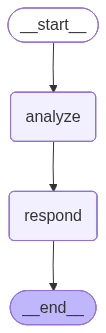

In [6]:
workflow